In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Load dataset
df = pd.read_csv("diabetes.csv")

print(df.head())
print(df.shape)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


In [3]:
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFun

In [4]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [5]:
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFun

In [6]:
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFun

In [7]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [8]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

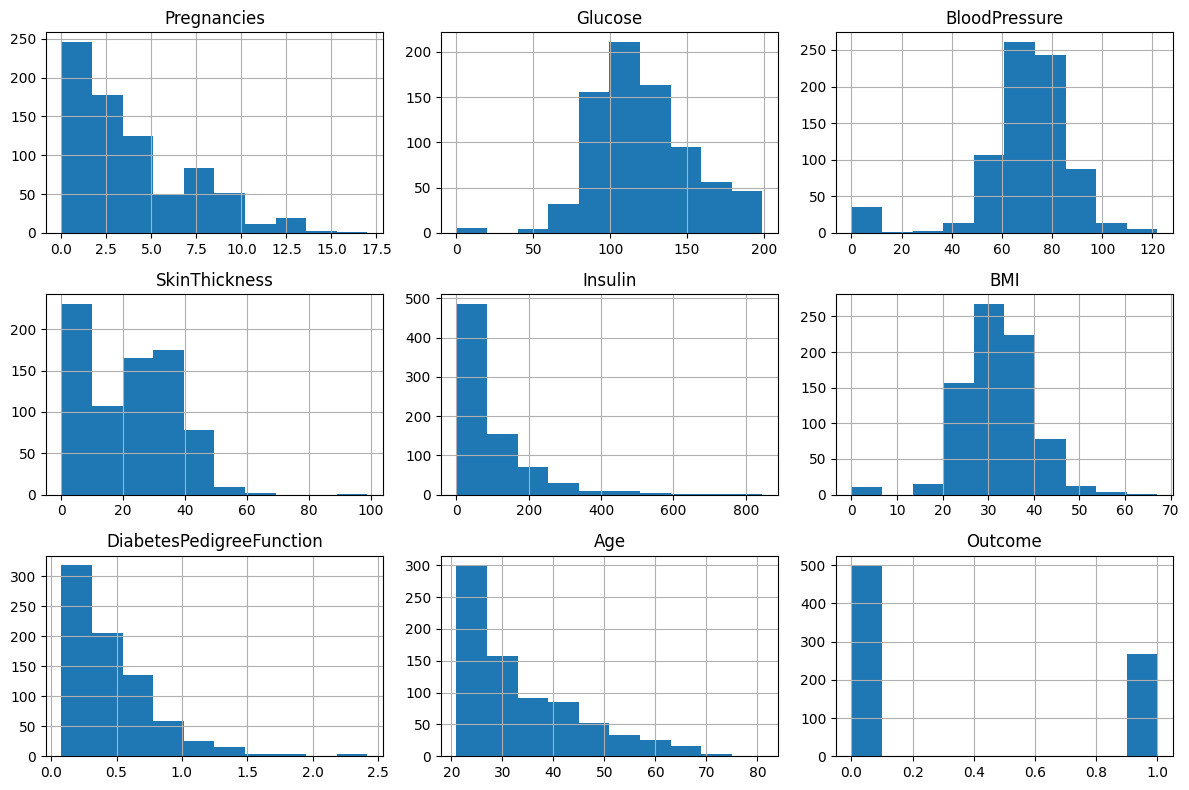

In [9]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

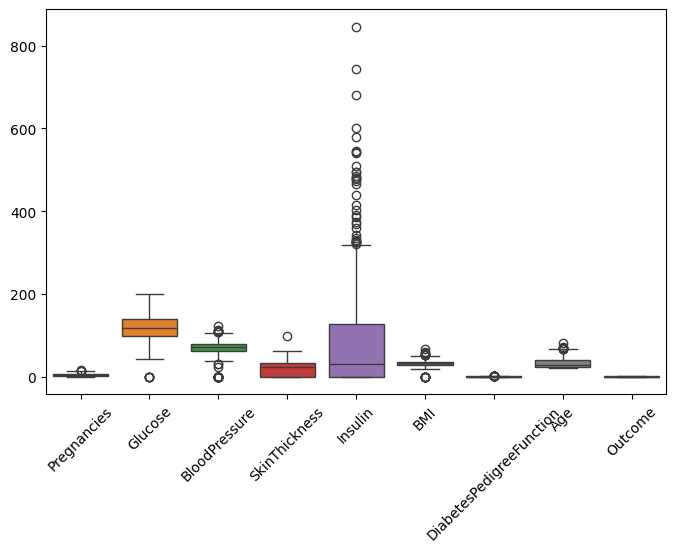

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=45)
plt.show()

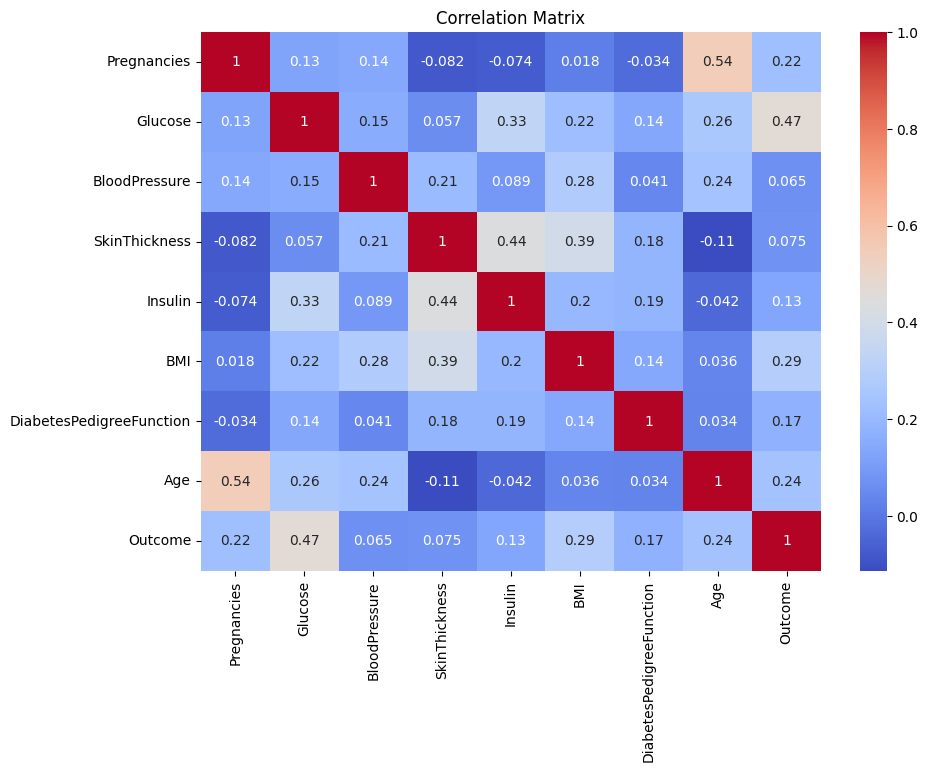

In [11]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [12]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

In [13]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [14]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[zero_columns] = X[zero_columns].replace(
    0,
    np.nan
)

X.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (614, 8)
X_test : (154, 8)
y_train: (614,)
y_test : (154,)


In [16]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)

X_test = imputer.transform(X_test)

In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
model = LogisticRegression(max_iter=1000)

model

LogisticRegression(max_iter=1000)

In [19]:
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [20]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1], dtype=int64)

In [21]:
y_probability = model.predict_proba(X_test)[:, 1]

y_probability[:10]

array([0.60969248, 0.11824675, 0.29337314, 0.25069934, 0.03351184,
       0.16845075, 0.48799869, 0.92361584, 0.08139997, 0.83860185])

In [22]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7077922077922078


In [23]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.6


In [24]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5


In [25]:
f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.5454545454545454


In [26]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.812962962962963


In [27]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454
ROC-AUC  : 0.812962962962963


In [28]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [29]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[82 18]
 [27 27]]


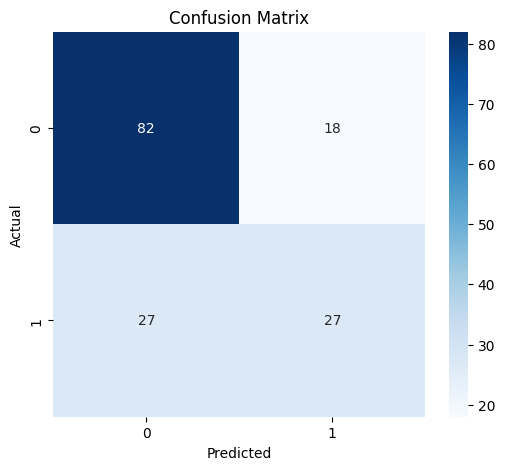

In [30]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

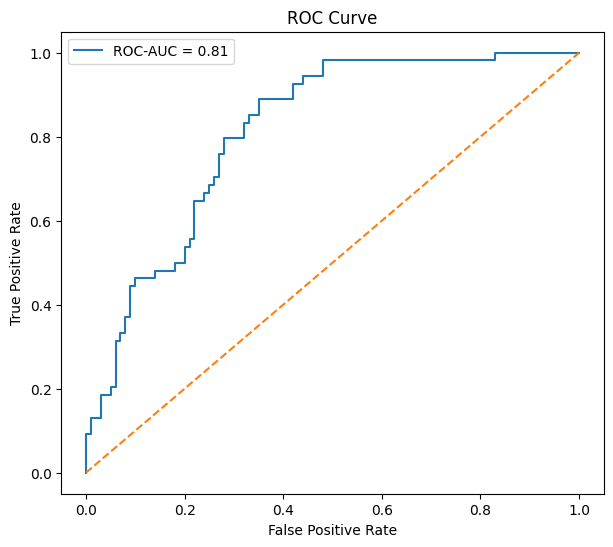

In [31]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.2f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [32]:
coefficients = model.coef_[0]

feature_names = df.drop(
    "Outcome",
    axis=1
).columns

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df

,Feature,Coefficient
0,Pregnancies,0.377160
1,Glucose,1.182626
2,BloodPressure,-0.044400
3,SkinThickness,0.028015
4,Insulin,-0.066214
5,BMI,0.688996
6,DiabetesPedigreeFunction,0.233229
7,Age,0.148338


In [33]:
coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

,Feature,Coefficient,Absolute_Coefficient
1,Glucose,1.182626,1.182626
5,BMI,0.688996,0.688996
0,Pregnancies,0.377160,0.377160
6,DiabetesPedigreeFunction,0.233229,0.233229
7,Age,0.148338,0.148338
4,Insulin,-0.066214,0.066214
2,BloodPressure,-0.044400,0.044400
3,SkinThickness,0.028015,0.028015


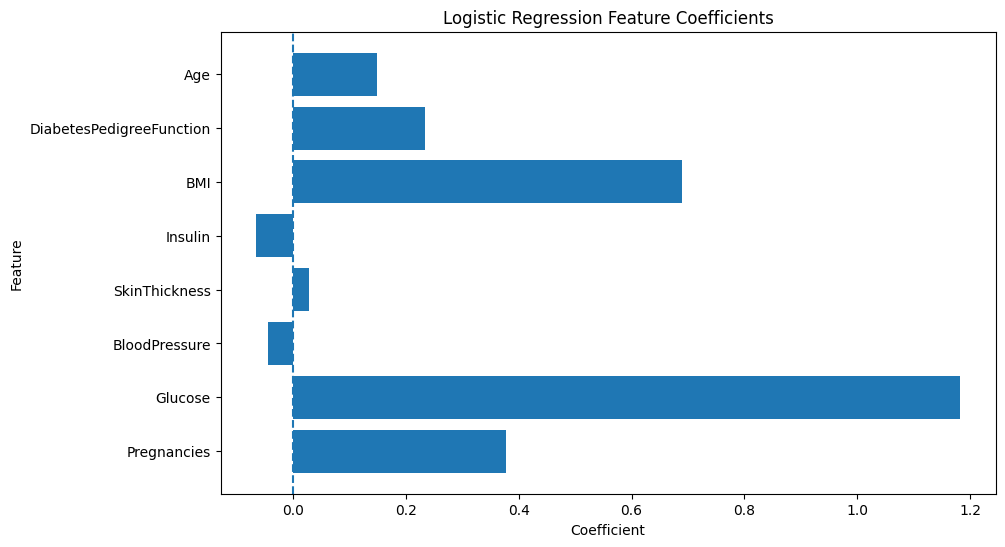

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_df["Feature"],
    coefficient_df["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.title(
    "Logistic Regression Feature Coefficients"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.show()

In [36]:
import joblib
artifacts = {
    "model": model,
    "imputer": imputer,
    "scaler": scaler
}

joblib.dump(
    artifacts,
    "diabetes_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [37]:
new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [120],
    "BloodPressure": [70],
    "SkinThickness": [20],
    "Insulin": [80],
    "BMI": [25.0],
    "DiabetesPedigreeFunction": [0.5],
    "Age": [30]
})

new_patient

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2,120,70,20,80,25.0,0.5,30


In [38]:
new_patient[zero_columns] = new_patient[
    zero_columns
].replace(0, np.nan)

new_patient_imputed = imputer.transform(
    new_patient
)

new_patient_scaled = scaler.transform(
    new_patient_imputed
)

In [39]:
prediction = model.predict(
    new_patient_scaled
)

probability = model.predict_proba(
    new_patient_scaled
)[0][1]

print("Prediction:", prediction[0])
print("Diabetes Probability:", probability)

Prediction: 0
Diabetes Probability: 0.13049792665773977


In [40]:
if prediction[0] == 1:
    print(
        f"Diabetes predicted "
        f"({probability * 100:.2f}% probability)"
    )
else:
    print(
        f"No diabetes predicted "
        f"({probability * 100:.2f}% probability)"
    )

No diabetes predicted (13.05% probability)


1.Precision tells us how many of the positive predictions made by the model were actually correct, while recall tells us how many of the actual positive cases the model was able to identify. Precision is important when we want to avoid false positives, while recall is important when we don't want to miss actual positive cases.

2.Cross-validation is a technique used to evaluate a machine learning model by dividing the dataset into multiple parts and training and testing the model several times. It is important in binary classification because it gives a more reliable idea of how the model will perform on unseen data, helps detect overfitting, and allows us to compare different models. Stratified K-Fold is commonly used so that both classes are properly represented in each fold.